In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import json

In [2]:
matrix_data = {'CADRL-Style': np.array([[0.01273517, 0.00772414, 0.00413081, 0.00307018, 0.00249066,
         0.00327422],
        [0.01853583, 0.0227972 , 0.02      , 0.00929615, 0.01127563,
         0.01192661],
        [0.02830441, 0.02985075, 0.02878788, 0.01534392, 0.01085114,
         0.01097955],
        [0.03680297, 0.05775   , 0.0329653 , 0.02031063, 0.01574179,
         0.01593111],
        [0.04359102, 0.0442618 , 0.03488372, 0.01767051, 0.02473451,
         0.01546499],
        [0.05931828, 0.04471199, 0.03411426, 0.02568845, 0.02392503,
         0.01171738]]),
 'DQN (Greedy)': np.array([[0.00972222, 0.02184874, 0.01447368, 0.01916933, 0.00222841,
         0.0023622 ],
        [0.00848896, 0.03763441, 0.03055556, 0.03030303, 0.00833333,
         0.01060606],
        [0.02228438, 0.01986864, 0.0253112 , 0.02634409, 0.01744831,
         0.01453184],
        [0.04199605, 0.0477131 , 0.02475806, 0.01985075, 0.02203065,
         0.01602289],
        [0.05431065, 0.04162437, 0.03361868, 0.02754221, 0.01903614,
         0.01467066],
        [0.0703559 , 0.06166896, 0.03542354, 0.02331861, 0.03516224,
         0.03234811]]),
 'Trivial': np.array([[0.02146341, 0.01904762, 0.01447368, 0.01122995, 0.00235988,
         0.00865385],
        [0.06538462, 0.02142857, 0.03122924, 0.0150289 , 0.01278772,
         0.01555024],
        [0.04894895, 0.07017544, 0.03683616, 0.02559694, 0.03445306,
         0.0125    ],
        [0.08722944, 0.08230769, 0.04495114, 0.0532967 , 0.0290404 ,
         0.01866516],
        [0.10859649, 0.07274074, 0.05059937, 0.03919308, 0.04174359,
         0.03575621],
        [0.14025974, 0.08623962, 0.0555205 , 0.05701021, 0.04498382,
         0.0416309 ]])}

matrix_data

{'CADRL-Style': array([[0.01273517, 0.00772414, 0.00413081, 0.00307018, 0.00249066,
         0.00327422],
        [0.01853583, 0.0227972 , 0.02      , 0.00929615, 0.01127563,
         0.01192661],
        [0.02830441, 0.02985075, 0.02878788, 0.01534392, 0.01085114,
         0.01097955],
        [0.03680297, 0.05775   , 0.0329653 , 0.02031063, 0.01574179,
         0.01593111],
        [0.04359102, 0.0442618 , 0.03488372, 0.01767051, 0.02473451,
         0.01546499],
        [0.05931828, 0.04471199, 0.03411426, 0.02568845, 0.02392503,
         0.01171738]]),
 'DQN (Greedy)': array([[0.00972222, 0.02184874, 0.01447368, 0.01916933, 0.00222841,
         0.0023622 ],
        [0.00848896, 0.03763441, 0.03055556, 0.03030303, 0.00833333,
         0.01060606],
        [0.02228438, 0.01986864, 0.0253112 , 0.02634409, 0.01744831,
         0.01453184],
        [0.04199605, 0.0477131 , 0.02475806, 0.01985075, 0.02203065,
         0.01602289],
        [0.05431065, 0.04162437, 0.03361868, 0.02754221, 

In [3]:
import pandas as pd
# Values
BOARD_SIZES = [50,60,70,80,90,100]
ROBOT_COUNTS = [5,10,15,20,25,30]
# Setup
state_dim = (2 * 10 + 1) ** 2 * 2 + 2
action_dim = 8
df_dict = {}
for name, matrix in matrix_data.items():
    df_dict[name] = pd.DataFrame(
        matrix,
        index=[f'{r} robots' for r in ROBOT_COUNTS],
        columns=[f'board={b}' for b in BOARD_SIZES]
    )

# Preview
for name, df in df_dict.items():
    print(f"\n{name}")
    print(df)


CADRL-Style
           board=50  board=60  board=70  board=80  board=90  board=100
5 robots   0.012735  0.007724  0.004131  0.003070  0.002491   0.003274
10 robots  0.018536  0.022797  0.020000  0.009296  0.011276   0.011927
15 robots  0.028304  0.029851  0.028788  0.015344  0.010851   0.010980
20 robots  0.036803  0.057750  0.032965  0.020311  0.015742   0.015931
25 robots  0.043591  0.044262  0.034884  0.017671  0.024735   0.015465
30 robots  0.059318  0.044712  0.034114  0.025688  0.023925   0.011717

DQN (Greedy)
           board=50  board=60  board=70  board=80  board=90  board=100
5 robots   0.009722  0.021849  0.014474  0.019169  0.002228   0.002362
10 robots  0.008489  0.037634  0.030556  0.030303  0.008333   0.010606
15 robots  0.022284  0.019869  0.025311  0.026344  0.017448   0.014532
20 robots  0.041996  0.047713  0.024758  0.019851  0.022031   0.016023
25 robots  0.054311  0.041624  0.033619  0.027542  0.019036   0.014671
30 robots  0.070356  0.061669  0.035424  0.023319 

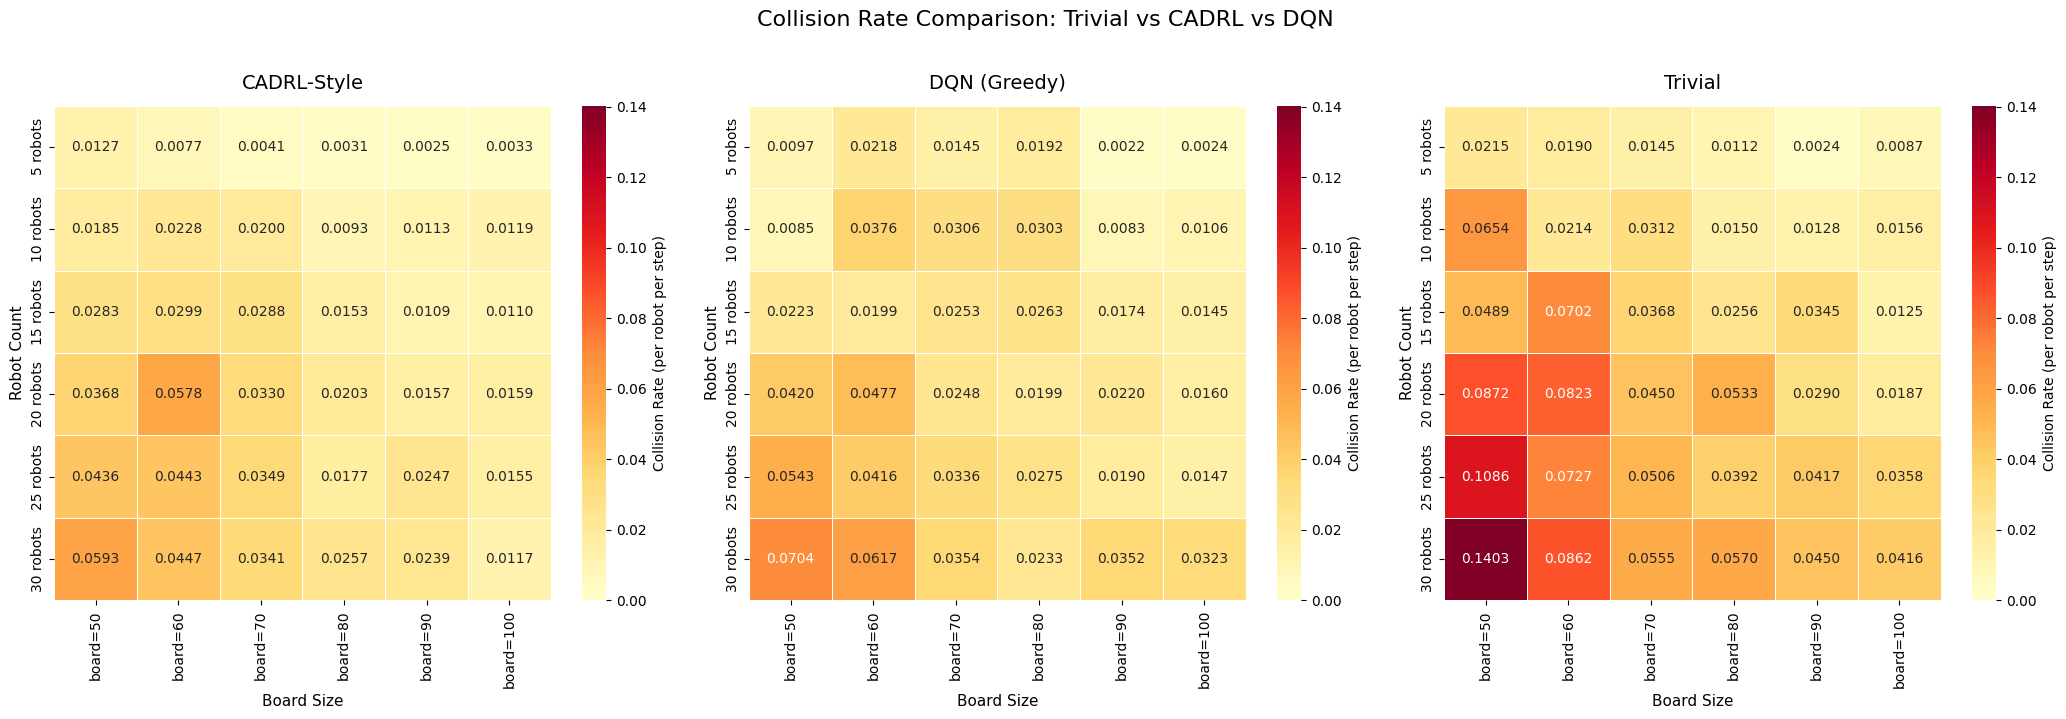

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(df_dict), figsize=(21, 7))

for ax, (name, df) in zip(axes, df_dict.items()):
    sns.heatmap(
        df,
        ax=ax,
        annot=True,
        fmt='.4f',
        cmap='YlOrRd',
        vmin=0,
        vmax=max(m.max() for m in matrix_data.values()),  # shared scale
        linewidths=0.5,
        cbar_kws={'label': 'Collision Rate (per robot per step)'}
    )
    ax.set_title(name, fontsize=14, pad=12)
    ax.set_xlabel('Board Size', fontsize=11)
    ax.set_ylabel('Robot Count', fontsize=11)

plt.suptitle('Collision Rate Comparison: Trivial vs CADRL vs DQN', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

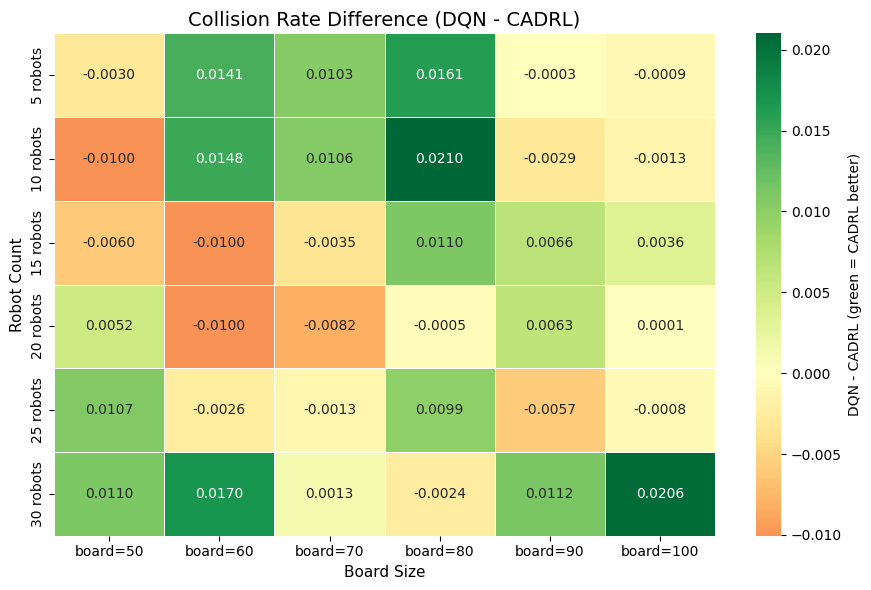

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

diff_df = df_dict['DQN (Greedy)'] - df_dict['CADRL-Style']  # positive = CADRL better

sns.heatmap(
    diff_df,
    ax=ax,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',   # red = DQN better, green = CADRL better
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'DQN - CADRL (green = CADRL better)'}
)
ax.set_title('Collision Rate Difference (DQN - CADRL)', fontsize=14)
ax.set_xlabel('Board Size', fontsize=11)
ax.set_ylabel('Robot Count', fontsize=11)
plt.tight_layout()
plt.show()

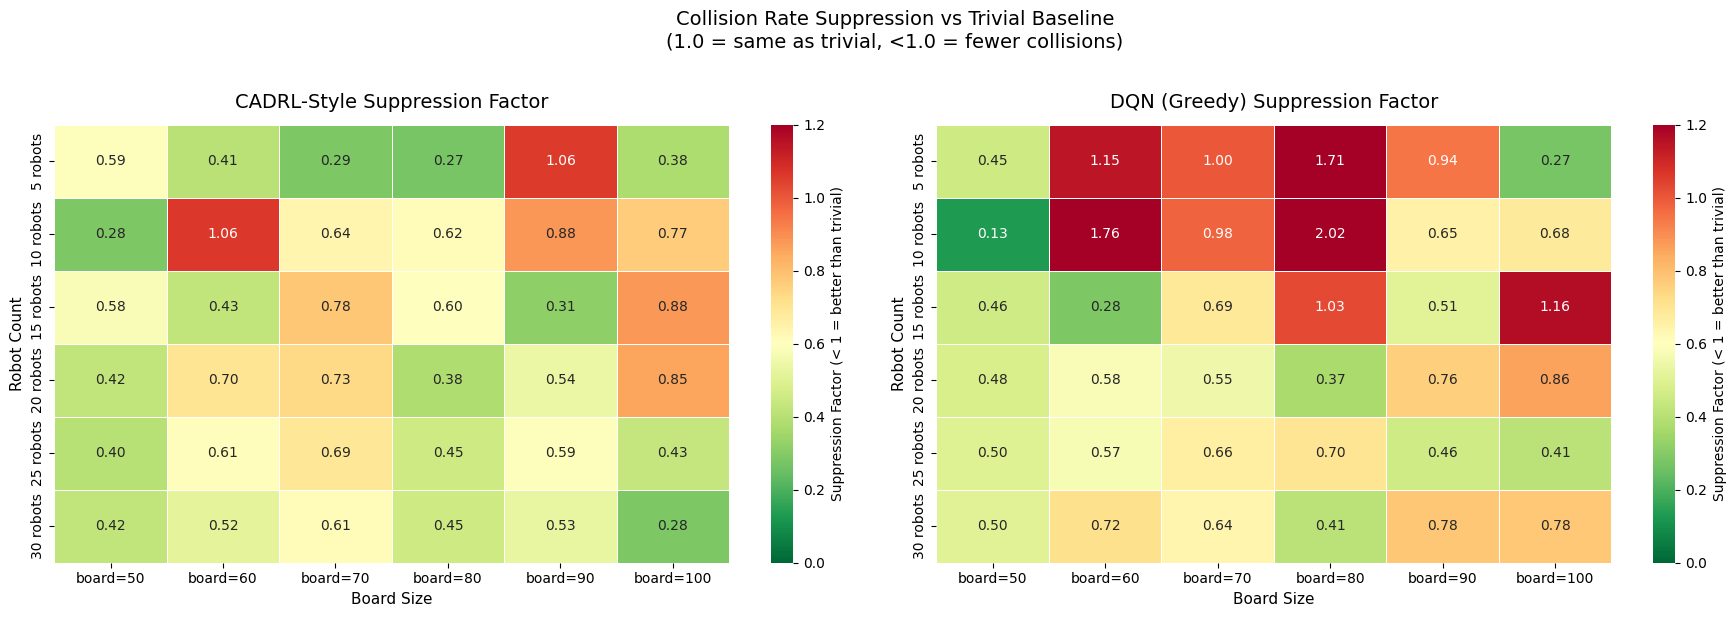

In [6]:
suppression = {
    name: df_dict[name] / df_dict['Trivial']
    for name in ['CADRL-Style', 'DQN (Greedy)']
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (name, df) in zip(axes, suppression.items()):
    sns.heatmap(
        df,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn_r',  # green = low suppression (better), red = high (worse)
        vmin=0,
        vmax=1.2,          # >1 means worse than trivial
        linewidths=0.5,
        cbar_kws={'label': 'Suppression Factor (< 1 = better than trivial)'}
    )
    ax.set_title(f'{name} Suppression Factor', fontsize=14, pad=12)
    ax.set_xlabel('Board Size', fontsize=11)
    ax.set_ylabel('Robot Count', fontsize=11)

plt.suptitle('Collision Rate Suppression vs Trivial Baseline\n(1.0 = same as trivial, <1.0 = fewer collisions)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

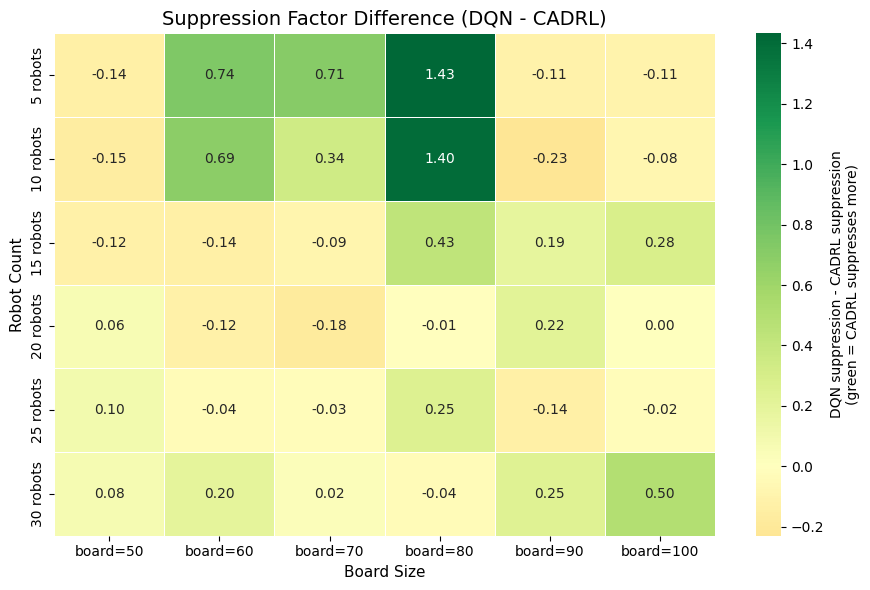

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

diff = suppression['DQN (Greedy)'] - suppression['CADRL-Style']  # positive = CADRL suppresses more

sns.heatmap(
    diff,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',   # green = CADRL better, red = DQN better
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'DQN suppression - CADRL suppression\n(green = CADRL suppresses more)'}
)
ax.set_title('Suppression Factor Difference (DQN - CADRL)', fontsize=14)
ax.set_xlabel('Board Size', fontsize=11)
ax.set_ylabel('Robot Count', fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
np.mean(suppression['CADRL-Style']), np.median(suppression['CADRL-Style'])

(0.5681359973444989, 0.560154323810697)

In [14]:
np.mean(suppression['DQN (Greedy)']), np.median(suppression['DQN (Greedy)']), 

(0.738671967861456, 0.6580378308469488)